In [103]:

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import ast

text_data = pd.read_csv('/Volumes/My_Passport/deeplearning/Text/processed_emotions.csv')
audio_data = pd.read_csv('/Volumes/My_Passport/deeplearning/Audio/audio_features_sample.csv')
video_data = pd.read_csv('/Volumes/My_Passport/deeplearning/Video/frame_mapping.csv')


In [104]:
def preprocess_data(df):
    if "input_ids" in df.columns and "attention_mask" in df.columns:
        for col in ["input_ids", "attention_mask"]:
            df[col] = df[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    if "labels" in df.columns:
        df.rename(columns={"labels": "emotion"}, inplace=True)
    return df

text_data = preprocess_data(text_data)



In [105]:

# Create a mapping for emotion labels
emotion_mapping = {"happy": 0, "sad": 1, "neutral": 2}
 
text_data["emotion"] = text_data["emotion"].map(emotion_mapping)
audio_data["emotion"] = audio_data["emotion"].map(emotion_mapping)
video_data["emotion"] = video_data["emotion"].map(emotion_mapping)

In [106]:
# Display columns for all datasets
print("Audio Features Columns:", audio_data.columns)
print("Processed Emotions Columns:", text_data.columns)
print("Frame Mapping Columns:", video_data.columns)


Audio Features Columns: Index(['file_path', 'emotion', 'mfcc_1', 'mfcc_2', 'mfcc_3', 'mfcc_4',
       'mfcc_5', 'mfcc_6', 'mfcc_7', 'mfcc_8', 'mfcc_9', 'mfcc_10', 'mfcc_11',
       'mfcc_12', 'mfcc_13', 'pitch', 'intensity'],
      dtype='object')
Processed Emotions Columns: Index(['input_ids', 'attention_mask', 'emotion'], dtype='object')
Frame Mapping Columns: Index(['frame_path', 'video_path', 'emotion'], dtype='object')


In [107]:
print(audio_data['emotion'].unique())
print(text_data['emotion'].unique())
print(video_data['emotion'].unique())


[1 0 2]
[0 2 1]
[1 0 2]


In [108]:
all_columns = list(set(audio_data.columns) | set(video_data.columns) | set(text_data.columns))


In [109]:
audio_data_aligned = audio_data.reindex(columns=all_columns)
video_data_aligned = video_data.reindex(columns=all_columns)
text_data_aligned = text_data.reindex(columns=all_columns)

# Add source column
audio_data_aligned["source"] = "audio"
video_data_aligned["source"] = "video"
text_data_aligned["source"] = "text"

# Concatenate datasets
combined_data = pd.concat([audio_data_aligned, video_data_aligned, text_data_aligned], axis=0)
combined_data.to_csv("combined_vertical_multimodal_data.csv", index=False)


In [110]:
print(combined_data['emotion'].unique())
label_map = {0: 0, 1: 1, 2: 2, "sad": 0, "neutral": 1, "happy": 2}
combined_data['emotion'] = combined_data['emotion'].replace({0: "sad", 1: "neutral", 2: "happy"})


[1 0 2]


In [111]:
train_data, temp_data = train_test_split(
    combined_data, test_size=0.3, stratify=combined_data["emotion"], random_state=42
)
val_data, test_data = train_test_split(
    temp_data, test_size=0.5, stratify=temp_data["emotion"], random_state=42
)

In [112]:
import numpy as np

class MultimodalDataset(Dataset):
    def __init__(self, dataframe):
        self.data = dataframe

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        # Handle text data
        try:
            if isinstance(row["input_ids"], list):
                input_ids = torch.tensor(row["input_ids"], dtype=torch.long)
            elif isinstance(row["input_ids"], str):
                input_ids = torch.tensor(eval(row["input_ids"]), dtype=torch.long)
            else:
                input_ids = torch.tensor([0] * 128, dtype=torch.long)  # Default value
        except Exception as e:
            print(f"Error processing input_ids at index {idx}: {e}")
            input_ids = torch.tensor([0] * 128, dtype=torch.long)

        try:
            if isinstance(row["attention_mask"], list):
                attention_mask = torch.tensor(row["attention_mask"], dtype=torch.long)
            elif isinstance(row["attention_mask"], str):
                attention_mask = torch.tensor(eval(row["attention_mask"]), dtype=torch.long)
            else:
                attention_mask = torch.tensor([0] * 128, dtype=torch.long)  # Default value
        except Exception as e:
            print(f"Error processing attention_mask at index {idx}: {e}")
            attention_mask = torch.tensor([0] * 128, dtype=torch.long)

        text_data = {"input_ids": input_ids, "attention_mask": attention_mask}

        # Handle audio data (use a placeholder for now)
        audio_data = torch.tensor(row.get("audio_features", [0.0] * 128), dtype=torch.float32)

        # Handle video data (use a placeholder for now)
        video_data = torch.tensor(row.get("video_features", [0.0] * 128), dtype=torch.float32)

        # Labels
        label_map = {"sad": 0, "neutral": 1, "happy": 2}  # Adjust based on your dataset
        emotion = row.get("emotion")
        if emotion not in label_map:
            raise KeyError(f"Invalid or missing emotion label at index {idx}: {emotion}")
        label = torch.tensor(label_map[emotion], dtype=torch.long)

        return text_data, audio_data, video_data, label




# DataLoaders
train_dataset = MultimodalDataset(train_data)
val_dataset = MultimodalDataset(val_data)
test_dataset = MultimodalDataset(test_data)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [113]:
print(f"Train Size: {len(train_dataset)}")
print(f"Validation Size: {len(val_dataset)}")
print(f"Test Size: {len(test_dataset)}")

Train Size: 4139
Validation Size: 887
Test Size: 887


In [114]:
# Models
class TextEmotionModel(nn.Module):
    def __init__(self, input_size, text_hidden):
        super(TextEmotionModel, self).__init__()
        self.input_projection = nn.Linear(input_size, text_hidden)  # Project input to text_hidden size
        self.fc = nn.Linear(text_hidden, text_hidden)

    def forward(self, input_ids, attention_mask):
        # Convert input_ids to float before feeding to the linear layer
        input_ids = input_ids.float()
        text_features = self.input_projection(input_ids)
        return self.fc(text_features)

class AudioEmotionModel(nn.Module):
    def __init__(self, input_size, audio_hidden):
        super(AudioEmotionModel, self).__init__()
        self.input_projection = nn.Linear(input_size, audio_hidden)  # Project input to audio_hidden size
        self.fc = nn.Linear(audio_hidden, audio_hidden)

    def forward(self, audio_features):
        projected_features = self.input_projection(audio_features)
        return self.fc(projected_features)


class VideoEmotionModel(nn.Module):
    def __init__(self, input_size, video_hidden):
        super(VideoEmotionModel, self).__init__()
        self.input_projection = nn.Linear(input_size, video_hidden)  # Project input to video_hidden size
        self.fc = nn.Linear(video_hidden, video_hidden)

    def forward(self, video_features):
        projected_features = self.input_projection(video_features)
        return self.fc(projected_features)


import torch
import torch.nn as nn

class MultimodalEmotionModel(nn.Module):
    def __init__(self, text_hidden, audio_hidden, video_hidden, num_classes):
        super(MultimodalEmotionModel, self).__init__()
        self.text_encoder = TextEmotionModel(128, text_hidden)  # Input size set to 128 for text
        self.audio_encoder = AudioEmotionModel(128, audio_hidden)  # Input size set to 128 for audio
        self.video_encoder = VideoEmotionModel(128, video_hidden)  # Input size set to 128 for video

        d_model = text_hidden + audio_hidden + video_hidden
        self.transformer_encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=8, dim_feedforward=4096, dropout=0.3, batch_first=True
    )

        self.transformer_encoder = nn.TransformerEncoder(self.transformer_encoder_layer, num_layers=4)

        # Add dropout to the final classifier layer
        self.fc = nn.Sequential(
            nn.Dropout(0.3),  # Increased dropout
            nn.Linear(d_model, num_classes)
        )

    def forward(self, text_inputs, audio_inputs, video_inputs):
        text_features = self.text_encoder(text_inputs["input_ids"], text_inputs["attention_mask"])
        audio_features = self.audio_encoder(audio_inputs)
        video_features = self.video_encoder(video_inputs)

        fused_features = torch.cat([text_features, audio_features, video_features], dim=1)
        fused_features = fused_features.unsqueeze(1)  # Add sequence dimension
        transformer_output = self.transformer_encoder(fused_features)
        transformer_output = transformer_output.squeeze(1)  # Remove sequence dimension
        return self.fc(transformer_output)


In [115]:
def train_model_with_scheduler(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs, device):
    model.to(device)
    best_val_loss = float('inf')
    patience_counter = 0
    training_loss_history = []
    validation_loss_history = []

    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0
        for text_inputs, audio_inputs, video_inputs, labels in train_loader:
            text_inputs = {k: v.to(device) for k, v in text_inputs.items()}
            audio_inputs = audio_inputs.to(device)
            video_inputs = video_inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(text_inputs, audio_inputs, video_inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)
        training_loss_history.append(train_loss)

        # Validation phase
        model.eval()
        val_loss = 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for text_inputs, audio_inputs, video_inputs, labels in val_loader:
                text_inputs = {k: v.to(device) for k, v in text_inputs.items()}
                audio_inputs = audio_inputs.to(device)
                video_inputs = video_inputs.to(device)
                labels = labels.to(device)

                outputs = model(text_inputs, audio_inputs, video_inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_loss /= len(val_loader)
        validation_loss_history.append(val_loss)
        scheduler.step(val_loss)

        # Save the best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), "best_model.pth")
        else:
            patience_counter += 1

        # Early stopping
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

        # Print epoch statistics
        print(f"Epoch {epoch + 1}/{epochs}")
        print(f"  Training Loss: {train_loss:.4f}")
        print(f"  Validation Loss: {val_loss:.4f}")

    # Plot training and validation loss
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 6))
    plt.plot(range(len(training_loss_history)), training_loss_history, label='Training Loss')
    plt.plot(range(len(validation_loss_history)), validation_loss_history, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()


Epoch 1/50
  Training Loss: 1.1425
  Validation Loss: 1.0492
Epoch 2/50
  Training Loss: 1.1101
  Validation Loss: 1.0569
Epoch 3/50
  Training Loss: 1.0960
  Validation Loss: 1.0661
Epoch 4/50
  Training Loss: 1.0903
  Validation Loss: 1.0697
Epoch 5/50
  Training Loss: 1.0861
  Validation Loss: 1.0759
Early stopping triggered.


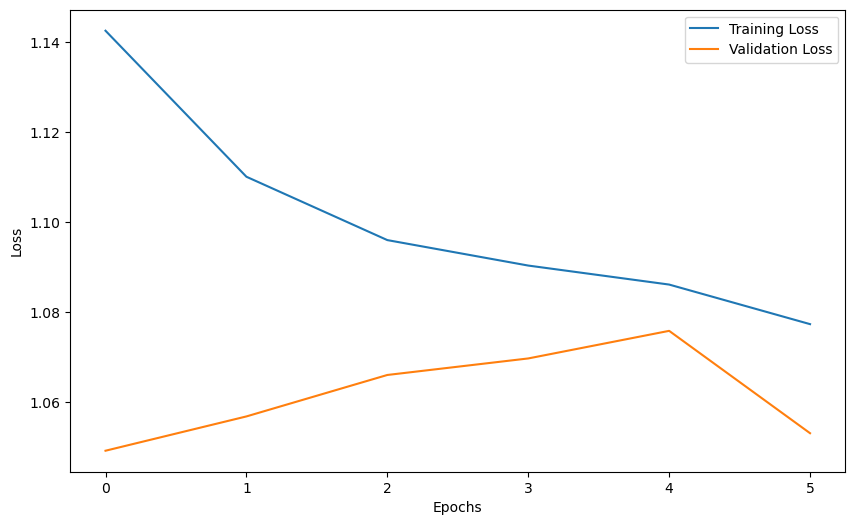

In [116]:
# Model initialization
text_hidden = 256
audio_hidden = 256
video_hidden = 256
num_classes = len(combined_data["emotion"].unique())

model = MultimodalEmotionModel(text_hidden, audio_hidden, video_hidden, num_classes)

# Define weighted loss for imbalanced data
class_weights = torch.tensor([1.0, 1.5, 2.0]).to(device)  # Adjust weights as needed
criterion = nn.CrossEntropyLoss(weight=class_weights)

patience = 5  # Early stopping after 5 epochs of no improvement

# Optimizer and scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

# Training settings
epochs = 50
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Train the model
train_model_with_scheduler(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs, device)


In [117]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, test_loader, device):
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for text_inputs, audio_inputs, video_inputs, labels in test_loader:
            text_inputs = {k: v.to(device) for k, v in text_inputs.items()}
            audio_inputs = audio_inputs.to(device)
            video_inputs = video_inputs.to(device)
            labels = labels.to(device)

            outputs = model(text_inputs, audio_inputs, video_inputs)
            _, preds = torch.max(outputs, 1)  # Get the predicted class

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Compute metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')

    print("Evaluation Metrics:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")

evaluate_model(model, test_loader, device)


Evaluation Metrics:
  Accuracy: 0.4307
  Precision: 0.2624
  Recall: 0.4307
  F1-Score: 0.3110


/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
